# Tissue closure in `tyssue`: lateral-face fusion and apical-constriction lift

This notebook demonstrates the **monolayer tissue-closure** tools:

1. **Lateral-face fusion** — joins two cells by welding the apposed free
   *lateral* wall of one to the other into a single internal interface
   (`tyssue.topology.bulk_topology`: `find_fusion_nucleations`,
   `find_fusion_propagations`, `fuse_lateral_faces`, `all_lateral_fusions`),
   driven through the `fuse` closure behavior and an `EventManager`.
2. **Apical-constriction lift** — a large circular monolayer doming out of
   the plane under apical line tension.

Fusion is **collision-triggered and polarity-typed**: it fires on *approach*
(distance + angle thresholds, no need for whole faces to coincide) and only
ever welds lateral↔lateral, apical-vertex↔apical-vertex, basal↔basal — so a
basal face can never fuse to a lateral one.

## Setup

In [1]:
import sys, pathlib
try:
    import tyssue  # noqa: F401
except ImportError:
    sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.spatial import Voronoi

from tyssue import Monolayer, MonolayerGeometry, Sheet, config
from tyssue.core.history import History
from tyssue.generation import extrude, from_2d_voronoi, hexa_disk
from tyssue.behaviors.event_manager import EventManager
from tyssue.behaviors.monolayer.closure_events import fuse
from tyssue.topology.bulk_topology import (
    find_fusion_nucleations, find_fusion_propagations,
    fuse_lateral_faces, all_lateral_fusions,
)
from tyssue.dynamics import effectors
from tyssue.dynamics.factory import model_factory
from tyssue.solvers.viscous import EulerSolver
from tyssue.draw.plt_draw import sheet_view_3d, create_gif_3d

import matplotlib.pyplot as plt
%matplotlib inline

geom = MonolayerGeometry
OUTPUT = pathlib.Path('closure_demo_output'); OUTPUT.mkdir(exist_ok=True)

C++ extensions are not available for this version
collision solver could not be imported You may need to install CGAL and re-install tyssue


In [2]:
import networkx as nx

def show3d(eptm, title='', view_angle=(25, -60), draw_order=('edge', 'vert')):
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')
    sheet_view_3d(
        eptm, ax=ax, coords=['x', 'y', 'z'], view_angle=view_angle,
        draw_order=draw_order,
        edge={'visible': True, 'color': '#1f3b5c', 'width': 1.0},
        vert={'visible': True, 'color': '#c1121f', 's': 8},
    )
    ax.set_title(title); plt.show()

def n_vertex_components(m):
    """Cells joined into one tissue if they share a vertex."""
    g = nx.Graph(); g.add_nodes_from(m.cell_df.index)
    for cells in m.edge_df.groupby('srce')['cell'].apply(set):
        cells = list(cells)
        for i in range(len(cells)):
            for j in range(i + 1, len(cells)):
                g.add_edge(cells[i], cells[j])
    return nx.number_connected_components(g)

## How lateral-face fusion works

`tyssue` stores an epithelium as a **half-edge mesh**: faces are loops of
directed edges; two faces sharing an interface are *opposite* (same vertices,
reversed winding). A face with `opposite == -1` is on a free surface — the
open walls of the tissue. In a monolayer the `segment` labels tell apical /
basal / lateral apart (a lateral wall has 2 apical and 2 basal vertices).

Closing a tissue is a **lateral↔lateral seam**: the free side-wall `g` of one
cell welds to the free side-wall `f` of another into one internal interface,
so the two cells become neighbours while the apical surface stays continuous
on one side and basal on the other. The weld matches **apical vertices to
apical, basal to basal** — so a basal face can never fuse to a lateral one,
by construction.

Two thresholds decide *when* to fuse (firing on approach, before contact, so
there's no interpenetration to resolve):

- **Nucleation** (two fronts first meet): two free lateral faces of
  **different, not-yet-adjacent** cells, normals anti-parallel to within
  `theta_face`, with a vertex of one within `d_max` of the other's plane.
- **Propagation** (zip along an existing seam): two free lateral faces that
  now **share a seam edge**, whose **fold angle** about that edge has closed
  below `theta_fold`. Same-front neighbours are excluded because their cells
  are already face-adjacent, so the regular boundary never fuses.

Both feed the same **quad-quad weld** (`fuse_lateral_faces`): vertices already
shared from a neighbouring fusion are left in place, the rest are welded;
`get_opposite_faces` then registers `g` and `f` as opposites. A weld that
would invalidate the mesh, or a genuine valence mismatch, is rolled
back/skipped. No fans, no extra edges — welding only removes vertices.

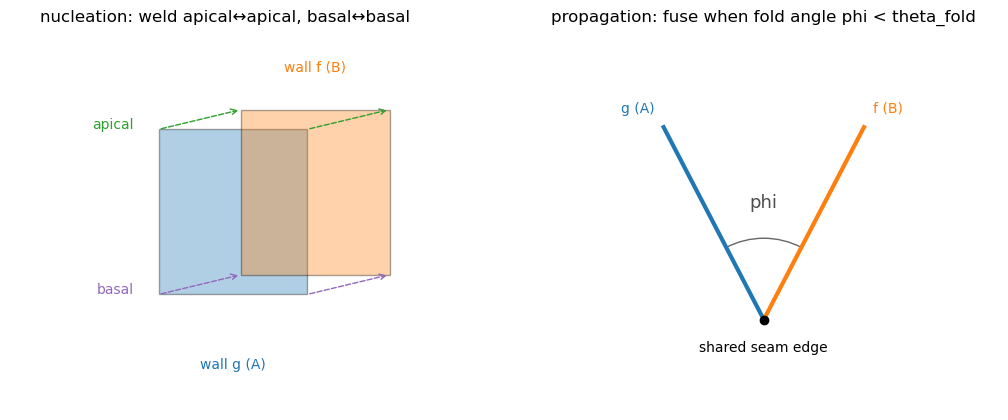

In [3]:
# Schematic: (left) nucleation weld; (right) propagation fold angle.
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Arc

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))
for ax in (axL, axR):
    ax.set_aspect('equal'); ax.axis('off')

# --- nucleation: two apposed lateral walls weld apical->apical, basal->basal
g = np.array([[0, 0], [0.9, 0], [0.9, 1], [0, 1]], float)   # basal row y=0, apical y=1
off = np.array([0.5, 0.12])
f = g + off
axL.add_patch(mpatches.Polygon(g, closed=True, fc='tab:blue', ec='k', alpha=.35))
axL.add_patch(mpatches.Polygon(f, closed=True, fc='tab:orange', ec='k', alpha=.35))
for a, b, col in [(g[3], f[3], 'tab:green'), (g[2], f[2], 'tab:green'),
                  (g[0], f[0], 'tab:purple'), (g[1], f[1], 'tab:purple')]:
    axL.add_patch(FancyArrowPatch(a, b, arrowstyle='->', mutation_scale=11,
                                  color=col, ls='--'))
axL.text(-0.15, 1.0, 'apical', ha='right', color='tab:green')
axL.text(-0.15, 0.0, 'basal', ha='right', color='tab:purple')
axL.text(0.45, -0.45, 'wall g (A)', color='tab:blue', ha='center')
axL.text(0.95, 1.35, 'wall f (B)', color='tab:orange', ha='center')
axL.set_xlim(-0.9, 1.7); axL.set_ylim(-0.7, 1.6)
axL.set_title('nucleation: weld apical\u2194apical, basal\u2194basal')

# --- propagation: two flaps hinged at a shared edge, fold angle phi
spine = np.array([0, 0])
phi = np.deg2rad(55)
L = 1.2
g2 = spine + L * np.array([np.cos(np.pi/2 + phi/2), np.sin(np.pi/2 + phi/2)])
f2 = spine + L * np.array([np.cos(np.pi/2 - phi/2), np.sin(np.pi/2 - phi/2)])
axR.plot(*np.c_[spine, g2], color='tab:blue', lw=3)
axR.plot(*np.c_[spine, f2], color='tab:orange', lw=3)
axR.scatter(*spine, color='k', zorder=3)
axR.add_patch(Arc(spine, 0.9, 0.9, angle=0,
                  theta1=np.degrees(np.pi/2 - phi/2), theta2=np.degrees(np.pi/2 + phi/2),
                  color='0.4'))
axR.text(0.0, 0.62, 'phi', ha='center', color='0.3', fontsize=13)
axR.text(spine[0], -0.18, 'shared seam edge', ha='center', color='k')
axR.text(*(g2 + [-0.05, 0.08]), 'g (A)', color='tab:blue', ha='right')
axR.text(*(f2 + [0.05, 0.08]), 'f (B)', color='tab:orange', ha='left')
axR.set_xlim(-1.3, 1.3); axR.set_ylim(-0.5, 1.6)
axR.set_title('propagation: fuse when fold angle phi < theta_fold')
plt.tight_layout(); plt.show()

## Part 1 — Two fronts joining on contact

In [4]:
def flat_monolayer(nx_=6, ny_=5):
    sheet = Sheet.planar_sheet_3d('flat', nx_, ny_, 1, 1)
    sheet.sanitize()
    mono = Monolayer('mono', extrude(sheet.datasets, method='translation'),
                     config.geometry.bulk_spec())
    geom.center(mono); geom.update_all(mono)
    mono.settings['threshold_length'] = 1e-2
    return mono

def incise(mono, axis='x'):
    """Cut the monolayer in two by duplicating the shared cut-line vertices."""
    mid = mono.cell_df[axis].median()
    left = set(mono.cell_df[mono.cell_df[axis] < mid].index)
    right = set(mono.cell_df[mono.cell_df[axis] >= mid].index)
    vc = mono.edge_df.groupby('srce')['cell'].apply(set)
    shared = [v for v, cs in vc.items() if (cs & left) and (cs & right)]
    ni = mono.vert_df.index.max() + 1
    rm = mono.edge_df['cell'].isin(right)
    for v in shared:
        row = mono.vert_df.loc[[v]].copy(); row.index = [ni]
        mono.vert_df = pd.concat([mono.vert_df, row])
        mono.edge_df.loc[rm & (mono.edge_df['srce'] == v), 'srce'] = ni
        mono.edge_df.loc[rm & (mono.edge_df['trgt'] == v), 'trgt'] = ni
        ni += 1
    mono.reset_index(); mono.reset_topo(); mono.get_opposite_faces(); geom.update_all(mono)
    left = set(mono.cell_df[mono.cell_df[axis] < mid].index)
    right = set(mono.cell_df[mono.cell_df[axis] >= mid].index)
    return left, right

def half_verts(mono, cells):
    return mono.edge_df[mono.edge_df['cell'].isin(cells)]['srce'].unique()

def offset_fronts(gap=0.0, shear=0.5):
    """Cut a monolayer in two and bring the halves together with a transverse
    shear, so the walls are NOT coincident."""
    mono = flat_monolayer()
    left, right = incise(mono)
    lv, rv = half_verts(mono, left), half_verts(mono, right)
    mono.vert_df.loc[rv, 'y'] += shear
    mono.vert_df.loc[lv, 'x'] -= gap / 2
    mono.vert_df.loc[rv, 'x'] += gap / 2
    geom.update_all(mono)
    return mono, left, right

### One lateral-face fusion on a real mesh

We cut a monolayer, **shear** the halves so the walls are offset by half a
cell (they do not line up), and overlap them. `find_fusion_nucleations`
returns an apposed pair of lateral walls `g` (blue) / `f` (orange) of
different cells; one `fuse_lateral_faces` welds them and the two fronts
become connected — note the vertex count *drops* (welds, no new edges).

components before: 2 | Nv = 98


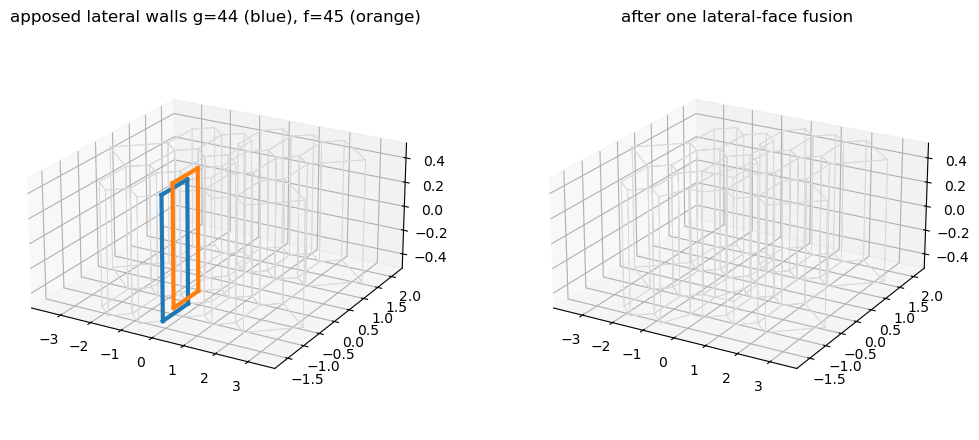

components after one fusion: 1 | Nv = 94 | valid=True


In [5]:
def draw_mesh(ax, m, hi_faces=()):
    P = m.vert_df[['x', 'y', 'z']]
    for s, t in m.edge_df[['srce', 'trgt']].to_numpy():
        ax.plot(*zip(P.loc[s], P.loc[t]), color='0.85', lw=0.6)
    for face, col in zip(hi_faces, ('tab:blue', 'tab:orange')):
        ef = m.edge_df[m.edge_df['face'] == face]
        for s, t in ef[['srce', 'trgt']].to_numpy():
            ax.plot(*zip(P.loc[s], P.loc[t]), color=col, lw=3)
    ax.view_init(22, -60); ax.set_box_aspect((1, 1, 0.5))

mono, left, right = offset_fronts(gap=-0.2)
g, f = find_fusion_nucleations(mono, d_max=0.5)[0]
print(f'components before: {n_vertex_components(mono)} | Nv = {mono.Nv}')

fig = plt.figure(figsize=(11, 4.5))
ax1 = fig.add_subplot(121, projection='3d')
draw_mesh(ax1, mono, hi_faces=(g, f))
ax1.set_title(f'apposed lateral walls g={g} (blue), f={f} (orange)')

fuse_lateral_faces(mono, g, f); geom.update_all(mono)

ax2 = fig.add_subplot(122, projection='3d')
draw_mesh(ax2, mono)
ax2.set_title('after one lateral-face fusion')
plt.tight_layout(); plt.show()
print(f'components after one fusion: {n_vertex_components(mono)} | Nv = {mono.Nv} | valid={mono.validate()}')

### Zipping the fronts together

Now we drive the closure through an `EventManager` with the `fuse` behavior:
the sheared halves are pushed together; a seam **nucleates** where they first
meet and then **propagates** along the shared edges (fold-angle trigger) until
the two fronts form a single connected tissue.

fronts at start: 2 components


after closure: 1 component | valid=True


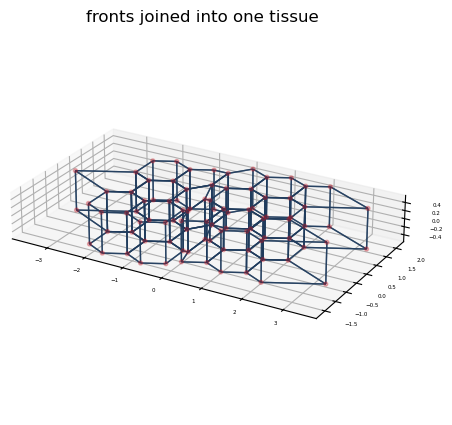

In [6]:
mono, left, right = offset_fronts(gap=0.8)
lv, rv = half_verts(mono, left), half_verts(mono, right)
print(f'fronts at start: {n_vertex_components(mono)} components')

manager = EventManager(); manager.append(fuse, d_max=0.4)
history = History(mono); history.record(time_stamp=0.0)

moved, step = 0.0, 0.15
for t in range(1, 15):
    if moved < 1.0:
        mono.vert_df.loc[lv, 'x'] += step / 2
        mono.vert_df.loc[rv, 'x'] -= step / 2
        moved += step; geom.update_all(mono)
    manager.update(); manager.execute(mono); geom.update_all(mono)
    left = {c for c in left if c in mono.cell_df.index}
    right = {c for c in right if c in mono.cell_df.index}
    lv, rv = half_verts(mono, left), half_verts(mono, right)
    history.record(time_stamp=float(t))

print(f'after closure: {n_vertex_components(mono)} component | valid={mono.validate()}')
show3d(mono, 'fronts joined into one tissue')

The whole zip as a 3D movie:

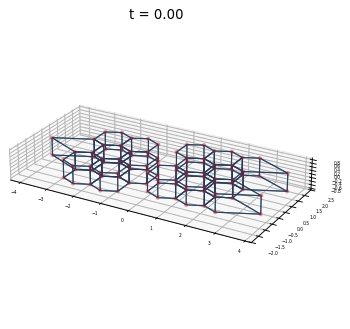

In [7]:
history.update_datasets()
gif = OUTPUT / 'offset_fronts_fusion.gif'
create_gif_3d(
    history, gif.as_posix(), num_frames=len(history.time_stamps),
    coords=['x', 'y', 'z'], draw_order=('edge', 'vert'),
    edge={'visible': True, 'color': '#1f3b5c', 'width': 1.0},
    vert={'visible': True, 'color': '#c1121f', 's': 8},
    view_angle=(25, -60), dpi=80,
)
from IPython.display import Image
Image(filename=gif.as_posix())

## Part 2 — Apical-constriction lift of a circular tissue

A large circular monolayer from a hexagonal disk of cell centres
(`hexa_disk`), sized so the **mean cell area ≈ 1** and **thickness = 1**.
Line tension on the **apical** edges constricts the apical surface and lifts
the tissue out of the plane. We integrate the viscous dynamics with
`EulerSolver`, ramping the apical line tension up to 1; a small initial dome
breaks the flat-disk symmetry.

118 cells | mean apical area = 0.997 | mean cell volume = 0.997


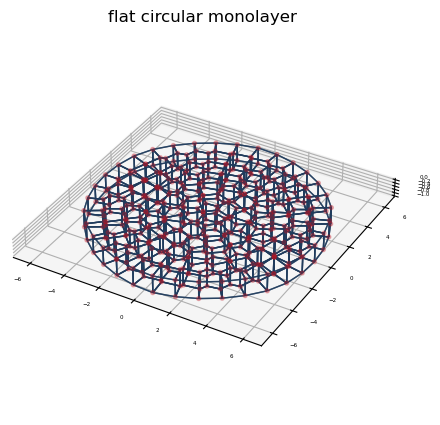

In [8]:
def circular_monolayer(num_t=40, radius=6.75):
    points = hexa_disk(num_t, radius)
    sheet = Sheet('disk', from_2d_voronoi(Voronoi(points)))
    sheet.sanitize(trim_borders=True, order_edges=True)
    sheet.reset_index(); sheet.reset_topo(); sheet.vert_df['z'] = 0.0
    mono = Monolayer('disk', extrude(sheet.datasets, method='translation', vector=[0, 0, -1.0]),
                     config.geometry.bulk_spec())
    geom.update_all(mono); mono.settings['threshold_length'] = 0.05
    return mono

mono = circular_monolayer()
print(f'{mono.Nc} cells | mean apical area = '
      f'{mono.face_df.loc[mono.apical_faces, "area"].mean():.3f} | '
      f'mean cell volume = {mono.cell_df["vol"].mean():.3f}')
show3d(mono, 'flat circular monolayer', view_angle=(35, -60))

In [9]:
model = model_factory(
    [effectors.LineTension, effectors.FaceContractility,
     effectors.FaceAreaElasticity, effectors.CellVolumeElasticity],
    effectors.CellVolumeElasticity,
)
mono.update_specs(model.specs, reset=False)
mono.face_df['area_elasticity'] = 1.0
mono.face_df['prefered_area'] = mono.face_df['area']
mono.cell_df['vol_elasticity'] = 1.0
mono.cell_df['prefered_vol'] = mono.cell_df['vol']
mono.vert_df['viscosity'] = 1.0
mono.face_df['contractility'] = 0.0
mono.edge_df['line_tension'] = 0.0

r = np.hypot(mono.vert_df['x'], mono.vert_df['y'])
mono.vert_df['z'] += 1.0 * (1.0 - (r / r.max()) ** 2)
geom.update_all(mono)

apical line tension = 1.0 | z-span = 2.52 | valid = True


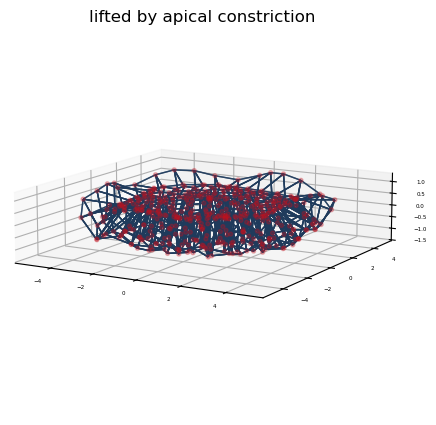

In [10]:
history = History(mono, save_every=4.0, dt=0.1)
solver = EulerSolver(mono, geom, model, history=history, bounds=(-0.5, 0.5))

for tension in np.linspace(0.2, 1.0, 9):
    mono.edge_df['line_tension'] = 0.0
    mono.edge_df.loc[mono.apical_edges, 'line_tension'] = tension
    solver.solve(tf=solver.prev_t + 15.0, dt=0.1)

geom.update_all(mono)
print(f'apical line tension = {mono.edge_df.loc[mono.apical_edges, "line_tension"].mean():.1f} | '
      f'z-span = {np.ptp(mono.vert_df["z"].to_numpy()):.2f} | valid = {mono.validate()}')
show3d(mono, 'lifted by apical constriction', view_angle=(12, -60))

The lift as a 3D movie:

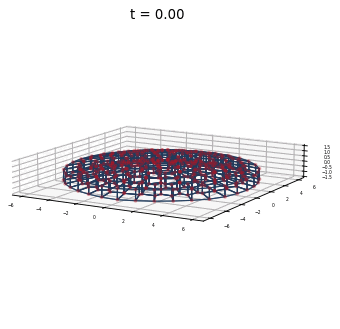

In [11]:
history.update_datasets()
gif = OUTPUT / 'circular_lift.gif'
create_gif_3d(
    history, gif.as_posix(), num_frames=len(history.time_stamps),
    coords=['x', 'y', 'z'], draw_order=('edge', 'vert'),
    edge={'visible': True, 'color': '#1f3b5c', 'width': 1.0},
    vert={'visible': True, 'color': '#c1121f', 's': 6},
    view_angle=(12, -60), dpi=80,
)
from IPython.display import Image
Image(filename=gif.as_posix())

## Notes

- **Lateral-face fusion** welds two apposed free lateral walls into one
  internal interface, matched per apico-basal segment, so polarity is
  preserved and a basal/lateral mis-fusion is impossible. It is triggered on
  approach by distance + facing angle (**nucleation**) and by the fold angle
  at a shared seam edge (**propagation**); same-front neighbours are excluded
  because their cells are already adjacent. Welding removes vertices rather
  than adding edges, and an invalid or valence-mismatched weld is rolled
  back / skipped.
- **Apical line tension alone** domes a flat disk into a stable open cup; it
  does not on its own bring the rim into self-contact. Closing a disk all the
  way into a sealed sphere needs an extra rim-closing cue to carry the front
  through contact, at which point the lateral-face fusion shown in Part 1
  seals it.